# Model Optimization - Bot Detection
## Hyperparameter Tuning & Advanced Optimization

## 1. Setup & Configuration

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     learning_curve, validation_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_auc_score, make_scorer)
import joblib
import os
from scipy.stats import randint, uniform

# Configuration
#plt.style.use('seaborn')
sns.set_palette('pastel')
%matplotlib inline

# Create output directories
os.makedirs('../models/optimized', exist_ok=True)
os.makedirs('../reports/optimization_plots', exist_ok=True)

## 2. Data Loading

In [25]:
# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

## 3. Optimization Strategy

In [26]:
# Define common parameters
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'AUC': 'roc_auc', 'F1': make_scorer(roc_auc_score)}

## 4. Random Forest Optimization

In [27]:
# Define parameter grid
rf_params = {
    'n_estimators': randint(100, 500),
    'max_depth': [None] + list(np.arange(5, 50, 5)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', {0:1, 1:3}]
}

print("=========== parameter grid ===========")
for param, values in rf_params.items():
    print(f"{param}: {values}")
print("======================================")

# Initialize search
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=100,
    scoring=scoring,
    refit='F1',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Execute search
rf_search.fit(X_train, y_train)

# Save best model
joblib.dump(rf_search.best_estimator_, '../models/optimized/rf_optimized.pkl')

=========== parameter grid ===========
n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D29D568410>
max_depth: [None, 5, 10, 15, 20, 25, 30, 35, 40, 45]
min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D29D583950>
min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D29D582110>
max_features: ['sqrt', 'log2', None]
class_weight: ['balanced', {0: 1, 1: 3}]
Fitting 5 folds for each of 100 candidates, totalling 500 fits


['../models/optimized/rf_optimized.pkl']

## 5. XGBoost Optimization

In [28]:
# Define parameter grid
xgb_params = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 1),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
    'scale_pos_weight': [3.0, 3.4, 4.0]
}

print("=========== parameter grid ===========")
for param, values in xgb_params.items():
    print(f"{param}: {values}")
print("======================================")

# Initialize search
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=100,
    scoring=scoring,
    refit='F1',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Execute search
xgb_search.fit(X_train, y_train)

# Save best model
joblib.dump(xgb_search.best_estimator_, '../models/optimized/xgb_optimized.pkl')

=========== parameter grid ===========
learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D29D89E3D0>
max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D29D89CE10>
subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D29D89C810>
colsample_bytree: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D29D89C2D0>
gamma: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D29D891810>
reg_alpha: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D29D893DD0>
reg_lambda: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D29D893910>
scale_pos_weight: [3.0, 3.4, 4.0]
Fitting 5 folds for each of 100 candidates, totalling 500 fits


['../models/optimized/xgb_optimized.pkl']

## 6. SVM Optimization

In [29]:
# Define parameter grid
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf'], 
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto'] 
}

print("=========== parameter grid ===========")
for param, values in svm_params.items():
    print(f"{param}: {values}")
print("======================================")

# Initialize search
svm_search = RandomizedSearchCV(
    estimator=SVC(class_weight='balanced', probability=True, random_state=42),
    param_distributions=svm_params,
    n_iter=50,
    scoring=scoring,
    refit='F1',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Execute search
svm_search.fit(X_train, y_train)

# Save best model
joblib.dump(svm_search.best_estimator_, '../models/optimized/svm_optimized.pkl')

=========== parameter grid ===========
C: [0.1, 1, 10, 100]
kernel: ['linear', 'poly', 'rbf']
degree: [2, 3, 4]
gamma: ['scale', 'auto']
Fitting 5 folds for each of 50 candidates, totalling 250 fits


['../models/optimized/svm_optimized.pkl']

In [30]:
# Save results to CSV
rf_results = pd.DataFrame(rf_search.cv_results_)
rf_results.to_csv('../reports/optimization_plots/rf_optimization_results.csv', index=False)
xgb_results = pd.DataFrame(xgb_search.cv_results_)
xgb_results.to_csv('../reports/optimization_plots/xgb_optimization_results.csv', index=False)
svm_results = pd.DataFrame(svm_search.cv_results_)
svm_results.to_csv('../reports/optimization_plots/svm_optimization_results.csv', index=False)

## 7. Optimization Analysis

In [31]:
# Load results
rf_results = pd.read_csv('../reports/optimization_plots/rf_optimization_results.csv')
xgb_results = pd.read_csv('../reports/optimization_plots/xgb_optimization_results.csv')
svm_results = pd.read_csv('../reports/optimization_plots/svm_optimization_results.csv')

# Load models 
rf_model = joblib.load('../models/optimized/rf_optimized.pkl')
xgb_model = joblib.load('../models/optimized/xgb_optimized.pkl')
svm_model = joblib.load('../models/optimized/svm_optimized.pkl')

In [39]:
# print the types of the columns in rf_results 
print(rf_results.dtypes)

mean_fit_time              float64
std_fit_time               float64
mean_score_time            float64
std_score_time             float64
param_class_weight          object
param_max_depth            float64
param_max_features          object
param_min_samples_leaf       int64
param_min_samples_split      int64
param_n_estimators           int64
params                      object
split0_test_AUC            float64
split1_test_AUC            float64
split2_test_AUC            float64
split3_test_AUC            float64
split4_test_AUC            float64
mean_test_AUC              float64
std_test_AUC               float64
rank_test_AUC                int64
split0_test_F1             float64
split1_test_F1             float64
split2_test_F1             float64
split3_test_F1             float64
split4_test_F1             float64
mean_test_F1               float64
std_test_F1                float64
rank_test_F1                 int64
dtype: object


In [47]:
# Display metrics
print("\n=== Baseline Model Performance (Random Forest) ===")
rf_f1 = rf_results.loc[rf_results['rank_test_F1'] == 1, 'mean_test_F1'].values[0]
print(f"F1 Score: {rf_f1:.4f}")
print(f"ROC AUC Score: {rf_results.loc[rf_results['rank_test_AUC'] == 1, 'mean_test_AUC'].values[0]:.4f}")
print(f"Best Parameters: {rf_results.loc[rf_results['rank_test_F1'] == 1, 'params'].values[0]}")

print("\n=== Baseline Model Performance (XGBoost) ===")
xgb_f1 = xgb_results.loc[xgb_results['rank_test_F1'] == 1, 'mean_test_F1'].values[0]
print(f"F1 Score: {xgb_f1:.4f}")
print(f"ROC AUC Score: {xgb_results.loc[xgb_results['rank_test_AUC'] == 1, 'mean_test_AUC'].values[0]:.4f}")
print(f"Best Parameters: {xgb_results.loc[xgb_results['rank_test_F1'] == 1, 'params'].values[0]}")

print("\n=== Baseline Model Performance (SVM) ===")
svm_f1 = svm_results.loc[svm_results['rank_test_F1'] == 1, 'mean_test_F1'].values[0]
print(f"F1 Score: {svm_f1:.4f}")
print(f"ROC AUC Score: {svm_results.loc[svm_results['rank_test_AUC'] == 1, 'mean_test_AUC'].values[0]:.4f}")
print(f"Best Parameters: {svm_results.loc[svm_results['rank_test_F1'] == 1, 'params'].values[0]}")



=== Baseline Model Performance (Random Forest) ===
F1 Score: 0.9412
ROC AUC Score: 0.9810
Best Parameters: {'class_weight': {0: 1, 1: 3}, 'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 403}

=== Baseline Model Performance (XGBoost) ===
F1 Score: 0.9457
ROC AUC Score: 0.9863
Best Parameters: {'colsample_bytree': 0.7996773519539009, 'gamma': 0.5720041992091831, 'learning_rate': 0.24056620429189268, 'max_depth': 3, 'reg_alpha': 0.994550510797341, 'reg_lambda': 0.46994451399094295, 'scale_pos_weight': 3.4, 'subsample': 0.9659457560881795}

=== Baseline Model Performance (SVM) ===
F1 Score: 0.9402
ROC AUC Score: 0.9816
Best Parameters: {'kernel': 'linear', 'gamma': 'scale', 'degree': 2, 'C': 0.1}


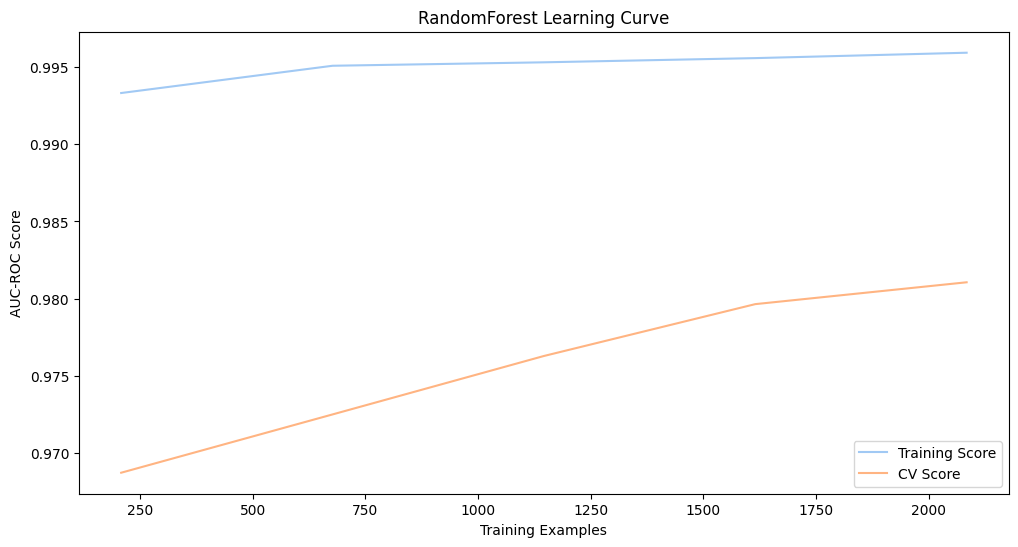

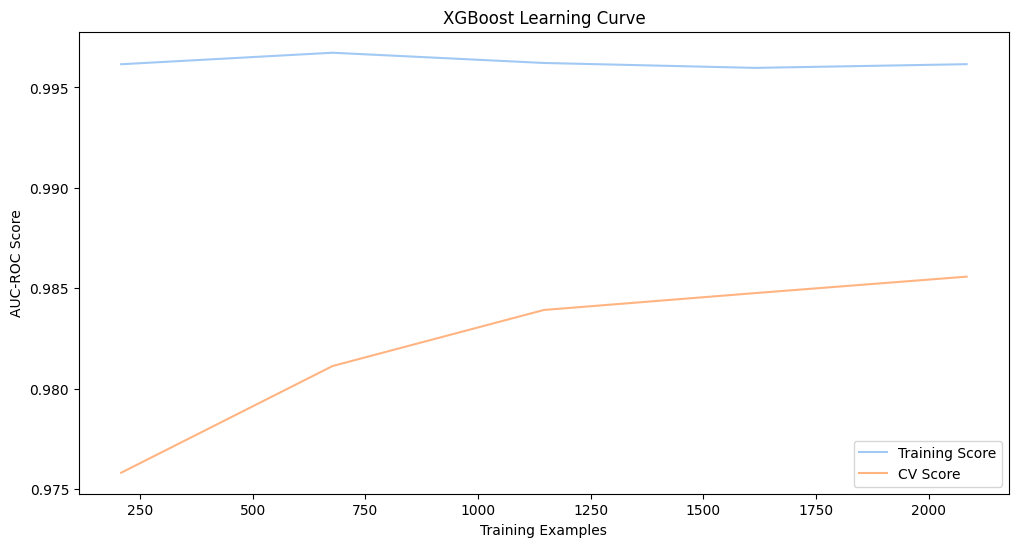

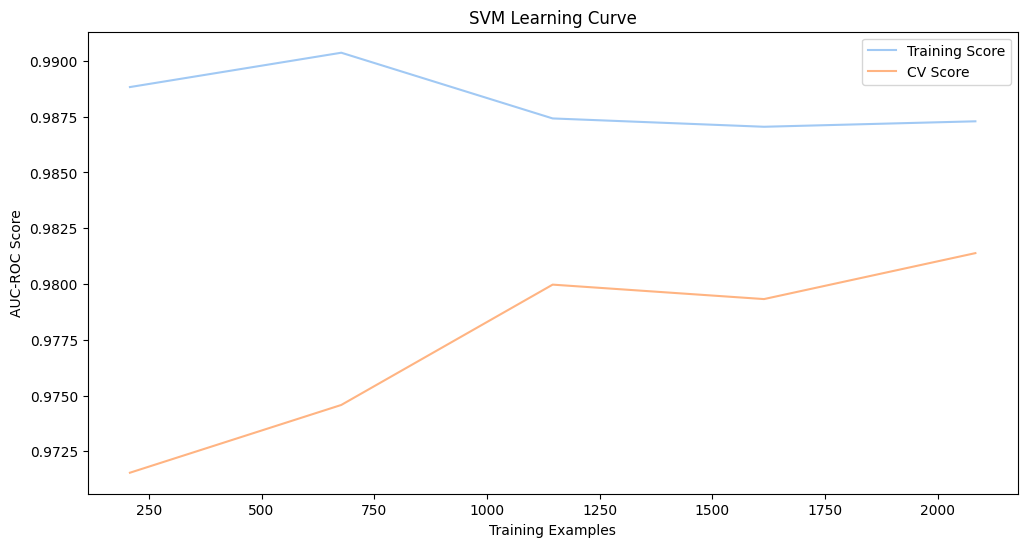

In [45]:
def plot_optimization_results(search, model_name):
    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        search.best_estimator_, X_train, y_train, cv=cv,
        scoring='roc_auc', n_jobs=-1
    )
    
    plt.figure(figsize=(12, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='CV Score')
    plt.title(f'{model_name} Learning Curve')
    plt.xlabel('Training Examples')
    plt.ylabel('AUC-ROC Score')
    plt.legend()
    plt.savefig(f'../reports/optimization_plots/{model_name}_learning_curve.png')
    plt.show()

# Plot for each model
plot_optimization_results(rf_search, 'RandomForest')
plot_optimization_results(xgb_search, 'XGBoost')
plot_optimization_results(svm_search, 'SVM')

## 8. Final Model Evaluation

In [33]:
optimized_models = {
    'Random Forest': joblib.load('../models/optimized/rf_optimized.pkl'),
    'XGBoost': joblib.load('../models/optimized/xgb_optimized.pkl'),
    'SVM': joblib.load('../models/optimized/svm_optimized.pkl')
}

results = []

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                 f1_score, roc_auc_score)


for name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })


In [34]:
# desplay metrics
print(results_df)

Model      Random Forest   XGBoost       SVM  Random Forest_baseline  \
AUC-ROC         0.977511  0.982576  0.978319                0.972526   
Accuracy        0.952454  0.953988  0.955521                0.955521   
F1              0.892734  0.898649  0.902357                     NaN   
F1-Score             NaN       NaN       NaN                0.898246   
Precision       0.908451  0.892617  0.893333                0.927536   
Recall          0.877551  0.904762  0.911565                0.870748   

Model      XGBoost_baseline  SVM_baseline  
AUC-ROC            0.976110      0.977187  
Accuracy           0.950920      0.950920  
F1                      NaN           NaN  
F1-Score           0.891156      0.892617  
Precision          0.891156      0.880795  
Recall             0.891156      0.904762  


In [35]:
# Compare results with baseline

#load baseline model
baseline_results = pd.read_csv('../reports/baseline_model_performance.csv')

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model').T
results_df = results_df.join(baseline_results.set_index('Model').T, how='outer', rsuffix='_baseline')
results_df = results_df.rename(columns={'Accuracy': 'Accuracy', 'Precision': 'Precision', 'Recall': 'Recall', 'F1': 'F1', 'AUC-ROC': 'AUC-ROC'})

# Save results
results_df.to_csv('../reports/optimized_model_performance.csv')


<Figure size 1200x600 with 0 Axes>

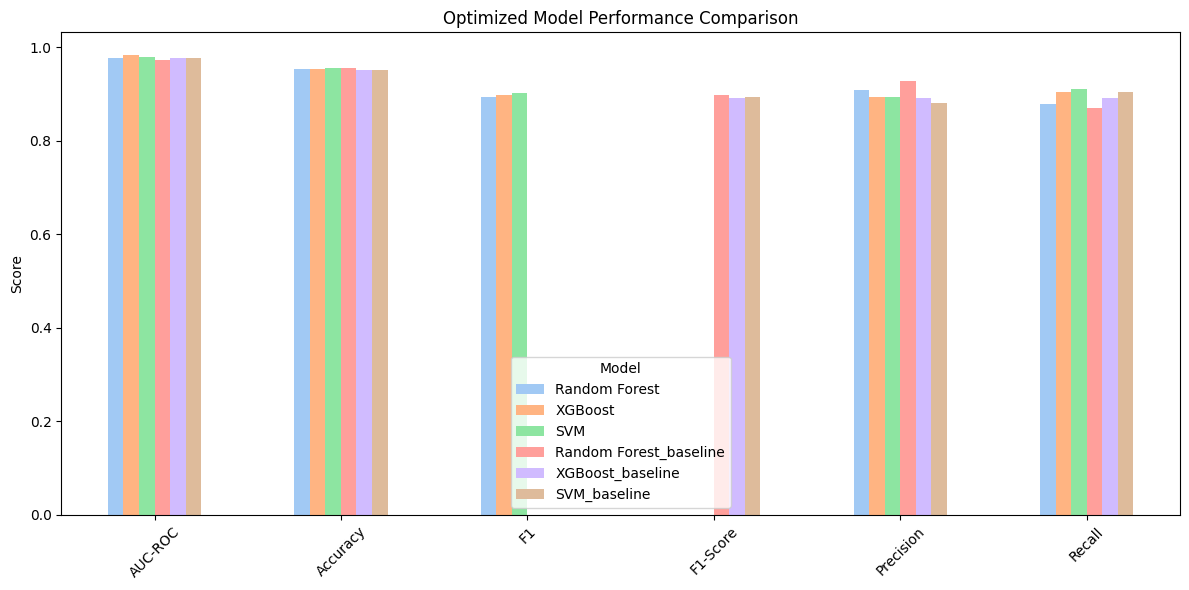

In [36]:
# plot comparison of optimized models with baseline
plt.figure(figsize=(12, 6))
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Optimized Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('../reports/optimization_plots/optimized_model_comparison.png')
plt.show()

## 9. Best Model Deployment

In [ ]:
# Identify best model
best_model = results_df.loc['AUC-ROC'].idxmax()

print("\n=== Best Model Performance ===")
print(f"\nBest Model: {best_model}")

# Save final model
joblib.dump(optimized_models[best_model], '../models/final_model.pkl')


=== Best Model Performance ===

Best Model: XGBoost


['../models/final_model.pkl']

## 10. Next Steps

**Recommended Actions**:
1. Conduct feature engineering on top predictors
2. Implement ensemble methods (stacking/voting)
3. Perform threshold optimization using precision-recall curves
4. Set up monitoring for concept drift